In [2]:
import pickle
from pathlib import Path
import pandas as pd
import numpy as np
import torch.nn as nn

from neuralhydrology.utils.config import Config

import matplotlib.pyplot as plt
import torch
from neuralhydrology.evaluation import metrics
from neuralhydrology.nh_run import start_run, eval_run

import os
##### Change this! #####
# grab colors for easy graphing
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
test_data_dir = Path("/Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/neuralhydrology/examples/07-DifferentialCFE-Model/testData")

minesColors = {
    "paleBlue":     "#CFDCE9",
    "lightBlue":    "#879EC3",
    "blasterBlue":  "#09396C",
    "darkBlue":     "#21314D",
    "coloradoRed":  "#CC4628",
    "lightGray":    "#AEB3B8",
    "silver":       "#81848A",
    "darkGray":     "#75757D",
    "goldenTech":   "#F1B91A",
    "earthBlue":    "#0272DE",
    "mutedBlue":    "#57A2BD",
    "energyYellow": "#F0F600",
    "envrGreen":    "#80C342",
    "redFlannel":   "#B42024"
    }

# Validation to CFE

In [3]:
# Defining a function that grabs weights & makes prediction
def load_lstm_and_predict(input_data, weights_path, input_size, hidden_size, num_layers, output_size):
    """
    Load LSTM weights and make predictions using a function-based approach.
    
    Args:
        input_data (torch.Tensor): Input tensor of shape (batch_size, seq_length, input_size).
        weights_path (str): Path to the .pt file containing model weights.
        input_size (int): Number of input features per time step.
        hidden_size (int): Number of features in the hidden state.
        num_layers (int): Number of recurrent layers.
        output_size (int): Number of output features.
    
    Returns:
        torch.Tensor: Predictions from the model.
    """
    # Define the LSTM and linear layers
    lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
    fc = nn.Linear(hidden_size, output_size)
    
    # Load weights
    state_dict = torch.load(weights_path)
    
    # Map LSTM weights
    lstm_state_dict = {k.replace("lstm.", ""): v for k, v in state_dict.items() if k.startswith("lstm.")}
    lstm.load_state_dict(lstm_state_dict)
    
    # Map fully connected (linear) layer weights
    if "linear.weight" in state_dict and "linear.bias" in state_dict:
        fc_state_dict = {
            "weight": state_dict["linear.weight"],
            "bias": state_dict["linear.bias"]
        }
        fc.load_state_dict(fc_state_dict)
    else:
        raise RuntimeError("Missing keys for linear layer in state_dict. Check the key names.")
    
    # Set evaluation mode
    lstm.eval()
    fc.eval()
    
    # Perform forward pass
    with torch.no_grad():
        lstm_out, _ = lstm(input_data)  # Get output from LSTM
        lstm_pred = fc(lstm_out)  # Pass through the fully connected layer
    
    # Apply sigmoid and scaling to each column
    predictions = torch.zeros_like(lstm_pred)
    predictions[:, :, 0] = torch.sigmoid(lstm_pred[:, :, 0]) * 0.000726 + 0.0 # satdk
    predictions[:, :, 1] = torch.sigmoid(lstm_pred[:, :, 1]) * (0.0018 - 0.0000018) + 0.0000018 # Cgw
    predictions[:, :, 2] = torch.sigmoid(lstm_pred[:, :, 2]) * 21.94 + 0.0 # bb
    predictions[:, :, 3] = torch.sigmoid(lstm_pred[:, :, 3]) * (1.0 - 0.20554) + 0.20554 # smcmax
    predictions[:, :, 4] = torch.sigmoid(lstm_pred[:, :, 4]) * 1.0 + 0.0 # slop
    predictions[:, :, 5] = torch.sigmoid(lstm_pred[:, :, 5]) * (0.25 - 0.01) + 0.01 # max_gw
    predictions[:, :, 6] = torch.sigmoid(lstm_pred[:, :, 6]) * (8.0 - 1.0) + 1.0 # expon
    predictions[:, :, 7] = torch.sigmoid(lstm_pred[:, :, 7]) * 1.0 + 0.0 # K_lf
    predictions[:, :, 8] = torch.sigmoid(lstm_pred[:, :, 8]) * 1.0 + 0.0 # K_nash
    predictions[:, :, 9] = torch.sigmoid(lstm_pred[:, :, 9]) * (0.95 - 0.05) + 0.05 # saptsi
    return predictions


Import trained model that makes predictions based on average of the LSTM output. Also grab calibrated parameters (this ver is via basin_id in config, later version grabs it differently.)

In [4]:
import neuralhydrology.utils.CFE_modules as module
from neuralhydrology.utils.DCFE_utils import get_dcfe_params, expand_dcfe_params_along_batch_dim

# Grab config file so we can see if the code works
config_path = Path('/Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/neuralhydrology/examples/07-DifferentialCFE-Model/2basinTest_devMultiBasin.yml')
config = Config(config_path, dev_mode=True)

# Define the path to the testData folder & grab data
inputLSTMFile = pd.read_csv(test_data_dir/'02177000_lstm_input.csv')

# Normalize the lstm input data
input_lstm = torch.zeros(config.batch_size, len(inputLSTMFile), len(inputLSTMFile.columns) - 1) # [batch_size = 2, time_steps, forcing]
# ^^^wierd batch size to minimum amout of code edits needed. Info will only be stored in [0,:,:]
input_lstm[0, :, 0] = torch.Tensor((inputLSTMFile['PRCP(mm/day)_nldas'].values - np.mean(inputLSTMFile['PRCP(mm/day)_nldas'].values))/
                                   np.std(inputLSTMFile['PRCP(mm/day)_nldas'].values))
input_lstm[0, :, 1] = torch.Tensor((inputLSTMFile['PRCP(mm/day)_maurer'].values - np.mean(inputLSTMFile['PRCP(mm/day)_maurer'].values))/
                                   np.std(inputLSTMFile['PRCP(mm/day)_maurer'].values))
input_lstm[0, :, 2] = torch.Tensor((inputLSTMFile['prcp(mm/day)_daymet'].values - np.mean(inputLSTMFile['prcp(mm/day)_daymet'].values))/
                                   np.std(inputLSTMFile['prcp(mm/day)_daymet'].values))
input_lstm[0, :, 3] = torch.Tensor((inputLSTMFile['srad(W/m2)_daymet'].values - np.mean(inputLSTMFile['srad(W/m2)_daymet'].values))/
                                   np.std(inputLSTMFile['srad(W/m2)_daymet'].values))
input_lstm[0, :, 4] = torch.Tensor((inputLSTMFile['tmax(C)_daymet'].values - np.mean(inputLSTMFile['tmax(C)_daymet'].values))/
                                   np.std(inputLSTMFile['tmax(C)_daymet'].values))
input_lstm[0, :, 5] = torch.Tensor((inputLSTMFile['tmin(C)_daymet'].values - np.mean(inputLSTMFile['tmin(C)_daymet'].values))/
                                   np.std(inputLSTMFile['tmin(C)_daymet'].values))
input_lstm[0, :, 6] = torch.Tensor((inputLSTMFile['vp(Pa)_daymet'].values - np.mean(inputLSTMFile['vp(Pa)_daymet'].values))/
                                   np.std(inputLSTMFile['vp(Pa)_daymet'].values))

# Grab config file that trained this model
config_path = Path('/Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/neuralhydrology/examples/07-DifferentialCFE-Model/runs/TestdCFEDaily_run02177000_CalibratedSpinUp15epoch_2302_114438/config.yml')
config = Config(config_path, dev_mode=True)

# Grab results from evaluated model (This is trained using Avg Params for Prediction)
run_dir = Path("/Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/neuralhydrology/examples/07-DifferentialCFE-Model/runs/TestdCFEDaily_run02177000_CalibratedSpinUp15epoch_2302_114438")
with open(run_dir / "test" / "model_epoch030" / "test_results.p", "rb") as fp:
    dCFE_results_avgParams = pickle.load(fp)

input_size = input_lstm.shape[2] # the num of forcings input into lstm, tmax, tmin, precip etc etc
hidden_size = config.hidden_size
num_layers = 1
output_size = 10 # satdk, cgw, and 7 other outputs
weights_path = run_dir/"model_epoch030.pt"

torch.set_printoptions(precision=16)

# Example input data (batch_size=1, seq_length=5, input_size=10)
input_data = input_lstm

# Make predictions
LSTM_params = load_lstm_and_predict(input_data, weights_path, input_size, hidden_size, num_layers, output_size)

dates_param = pd.date_range(start='1998-04-04', periods=input_lstm.shape[1], freq='D')

In [21]:
input_cfe = torch.zeros(config.batch_size, input_lstm.shape[1], 4) #[ "batch_size", forcings, time_step]
input_cfe[0, :, 0] = torch.tensor(inputLSTMFile['PRCP(mm/day)_nldas'].values) # 1998 - 2000, 2 water years
input_cfe[0, :, 1] = torch.tensor(inputLSTMFile['tmin(C)_daymet'].values)
input_cfe[0, :, 2] = torch.tensor(inputLSTMFile['tmax(C)_daymet'].values)
input_cfe[0, :, 3] = torch.tensor(inputLSTMFile['srad(W/m2)_daymet'].values)

#get_dcfe_params(config)
# store them as calibrated parameters for the calibrated-CFE comparison


#calibrated_soil_params_validate = expand_dcfe_params_along_batch_dim(temp_soil_params_validate, config.batch_size)
#calibrated_basinCharacteristics_validate = expand_dcfe_params_along_batch_dim(temp_basinCharacteristics_validate, config.batch_size)

## Verify Model to CFE & Previous Study
The goal of this section is to compare the existing dCFE code (as of 20241215) to CFE hourly outputs: https://github.com/NWC-CUAHSI-Summer-Institute/cfe_py/blob/main/cat58_test_compare.csv
The forcing for the same time period is: https://github.com/NWC-CUAHSI-Summer-Institute/cfe_py/blob/main/cat58_01Dec2015.csv
The basin settings (since baasin id unknown) is here: https://github.com/NWC-CUAHSI-Summer-Institute/cfe_py/blob/main/bmi_cfe.py

Note that the forcing file as TMP_2maboveground which I assume is temperature in (K), so it needs to be converted to C before being used. And the initialized_basin_constants is adaped based on the bmi_cfe.py file. 

### Running CFE

In [5]:
device = 'cpu'
batch_size = config.batch_size

forcingFile = pd.read_csv(test_data_dir/'cat58_01Dec2015.csv')
forcingsTest = torch.zeros(batch_size, forcingFile.shape[0], 3) #[ "batch_size", forcings, time_step]

forcingsTest[:, :, 0] = (torch.tensor(forcingFile.loc[:,'precip_rate']) * 1000 * 3600) # m/s to mm/hr
forcingsTest[:, :, 1] = (torch.tensor(forcingFile.loc[:,'TMP_2maboveground']) - 273.15) # K to C
forcingsTest[:, :, 2] = torch.tensor(forcingFile.loc[:,'DSWRF_surface']) # same unit as camels

In [ ]:
# empty vector to store output
Discharge = torch.zeros(forcingsTest.shape[1], 8)
    
# need to handle giuh differently
giuh = torch.tensor([0.1, 0.35, 0.2, 0.14, 0.1, 0.06, 0.05], dtype=torch.float32, device=device)

TShirt_basinCharacteristics = {
        'catchment_area_km2': 15.617167355002097 * torch.tensor(1.0, dtype=torch.float32, device=device).repeat(batch_size), 
        'refkdt': 3.8266861353378374 * torch.tensor(1.0, dtype=torch.float32, device=device).repeat(batch_size),
        'max_gw_storage': 16 * torch.tensor(1.0, dtype=torch.float32, device=device).repeat(batch_size),
        'Cgw': 0.01*torch.tensor(1.0).repeat(batch_size),
        'expon': 6.0 * torch.tensor(1.0, dtype=torch.float32, device=device).repeat(batch_size),
        #gw_storage = 0.05 * torch.ones((  batch_size,  shape[1]), dtype=torch.float32, device= device)
        'alpha_fc': 0.33 * torch.tensor(1.0, dtype=torch.float32, device=device).repeat(batch_size ),
        'K_nash': 0.03 * torch.tensor(1.0, dtype=torch.float32, device= device).repeat(  batch_size), 
        'K_lf': 0.01 * torch.tensor(1.0, dtype=torch.float32, device= device).repeat(  batch_size), 
        'nash_storage': torch.zeros((  batch_size,2), dtype=torch.float32, device= device),
        'giuh_ordinates': giuh.unsqueeze(0).repeat(batch_size, 1)
    } 


TShirt_soil_params = {
        'depth': 2.0 * torch.tensor(1.0, dtype=torch.float32, device= device).repeat(  batch_size), # not sure where they got these values, they don't match CAMELS, [m]
        'bb': 4.05 * torch.tensor(1.0, dtype=torch.float32, device= device).repeat(  batch_size), # exponent on Clapp-Hornberger function, part of calibration
        'satdk': 0.00000338*torch.tensor(1.0).repeat(  batch_size),
        'satpsi': 0.355 * torch.tensor(1.0, dtype=torch.float32, device= device).repeat(  batch_size), 
        'slop': 1 * torch.tensor(1.0, dtype=torch.float32, device= device).repeat(  batch_size), # slope coefficient, part of calibration
        'smcmax': 0.439 * torch.tensor(1.0, dtype=torch.float32, device= device).repeat(  batch_size), # maximum soil moisture content [m3/m3], part of calibration
        'wltsmc': 0.066* torch.tensor(1.0, dtype=torch.float32, device= device).repeat(  batch_size),
        'D': 2.0 * torch.tensor(1.0, dtype=torch.float32, device= device).repeat(  batch_size),
        'mult': 1000.0 * torch.tensor(1.0, dtype=torch.float32, device= device).repeat(  batch_size)
    }

TShirt_params = {
    'soil_params': TShirt_soil_params,
    'basinCharacteristics': TShirt_basinCharacteristics
}

# initialize before run
constants, cfe_params, gw_reservoir, soil_reservoir, routing_info, flux = module.initialize_basin_constants(
    cfg= config,
    conceptual_forcing= forcingsTest,
    cfe_params= TShirt_params,
    hourly= True
    )


# unique to T-shirt
gw_reservoir['storage_m'] = gw_reservoir['storage_max_m'].clone() * 0.03125
soil_reservoir['storage_m'] = 0.667 * torch.tensor(1.0, dtype=torch.float32, device=device).repeat(batch_size) #factor was 0.6 before

timestep_params_TShirt = {
    'satdk': TShirt_soil_params['satdk'],
    'Cgw': TShirt_basinCharacteristics['Cgw'],
    'bb': TShirt_soil_params['bb'],
    'smcmax': TShirt_soil_params['smcmax'],
    'slop': TShirt_soil_params['slop'],
    'max_gw_storage': TShirt_basinCharacteristics['max_gw_storage'],
    'expon': TShirt_basinCharacteristics['expon'],
    'K_lf': TShirt_basinCharacteristics['K_lf'],
    'K_nash': TShirt_basinCharacteristics['K_nash'],
    'satpsi': TShirt_soil_params['satpsi']
    }


for i in range(forcingsTest.shape[1]):
    cfe_params, gw_reservoir, soil_reservoir, routing_info, flux = module.timestep_CFE_new(
        x_conceptual_timestep= forcingsTest[:, i, :],
        cfe_params=cfe_params,
        timestep_parameters= timestep_params_TShirt,
        constants= constants,
        gw_reservoir= gw_reservoir,
        soil_reservoir= soil_reservoir,
        routing_info= routing_info,
        flux = flux,
        hourly= True
        )

    Discharge[i, 0] = flux['Qout_m'][0] # runoff in m/timestep
    Discharge[i, 1] = flux['giuh_runoff_m'][0] 
    Discharge[i, 2] = flux['nash_lateral_runoff_m'][0]
    Discharge[i, 3] = flux['from_deep_gw_to_chan_m'][0]
    Discharge[i, 4] = flux['surface_runoff_depth_m'][0]
    Discharge[i, 5] = flux['actual_et_m_per_timestep'][0] # total ET
    Discharge[i, 6] = soil_reservoir['storage_m'][0] # soil water storage
    Discharge[i, 7] = gw_reservoir['storage_m'][0] # gw storage


# grab observations from acutal CFE
compareFile = pd.read_csv(test_data_dir/'cat58_test_compare.csv')

### Comparison to T-Shirt CFE

This only looks at one section of the whole time series, the same section that the original comparison did (not sure why they picked this specific section).

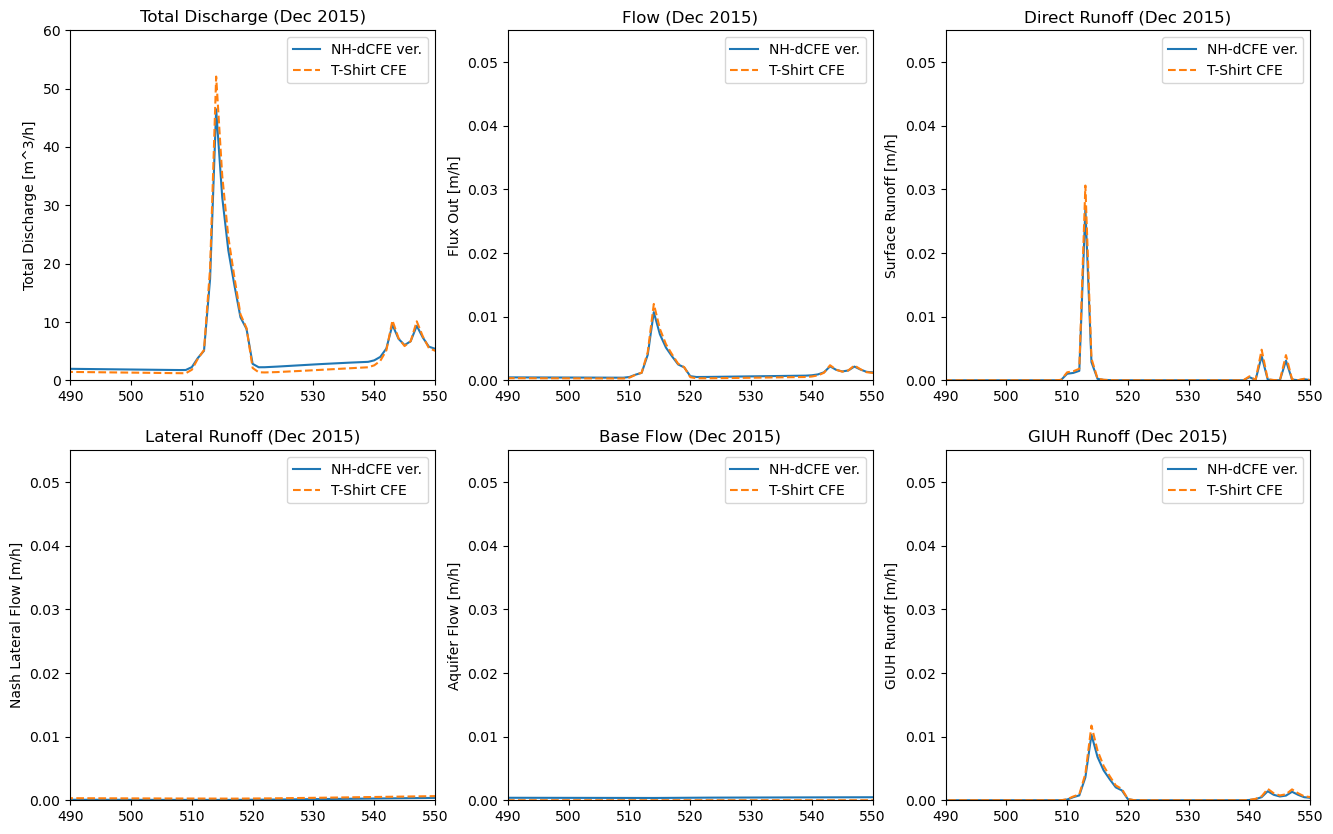

In [19]:
fig, ax = plt.subplots(2, 3, figsize=(16,10))

ax[0,0].plot(compareFile['Time Step'], Discharge[:,0]*15.617167355002097 * 1000000.0 / 3600 , label="NH-dCFE ver.")
ax[0,0].plot(compareFile['Time Step'], compareFile['Total Discharge'], label="T-Shirt CFE", linestyle= 'dashed')
# Set labels and title
ax[0,0].set_ylabel("Total Discharge [m^3/h]")
ax[0,0].set_title(f"Total Discharge (Dec 2015)")
# Set axis limits
ax[0,0].set_xlim([490, 550]) 
ax[0,0].set_ylim([0, 60])  
ax[0,0].legend()

ax[0,1].plot(compareFile['Time Step'], Discharge[:,0], label="NH-dCFE ver.")
ax[0,1].plot(compareFile['Time Step'], compareFile['Flow'], label="T-Shirt CFE", linestyle= 'dashed')
# Set labels and title
ax[0,1].set_ylabel("Flux Out [m/h]")
ax[0,1].set_title(f"Flow (Dec 2015)")
# Set axis limits
ax[0,1].set_xlim([490, 550])  
ax[0,1].set_ylim([0, 0.055])  
ax[0,1].legend()

ax[0,2].plot(compareFile['Time Step'], Discharge[:,4], label="NH-dCFE ver.")
ax[0,2].plot(compareFile['Time Step'], compareFile['Direct Runoff'],label="T-Shirt CFE", linestyle = 'dashed')
# Set labels and title
ax[0,2].set_ylabel("Surface Runoff [m/h]")
ax[0,2].set_title(f"Direct Runoff (Dec 2015)")
# Set axis limits
ax[0,2].set_xlim([490, 550]) 
ax[0,2].set_ylim([0, 0.055])  
ax[0,2].legend()

ax[1,0].plot(compareFile['Time Step'], Discharge[:,2], label="NH-dCFE ver.")
ax[1,0].plot(compareFile['Time Step'], compareFile['Lateral Flow'],label="T-Shirt CFE", linestyle = 'dashed')
# Set labels and title
ax[1,0].set_ylabel("Nash Lateral Flow [m/h]")
ax[1,0].set_title(f"Lateral Runoff (Dec 2015)")
# Set axis limits
ax[1,0].set_xlim([490, 550]) 
ax[1,0].set_ylim([0, 0.055])   
ax[1,0].legend()

ax[1,1].plot(compareFile['Time Step'], Discharge[:,3], label="NH-dCFE ver.")
ax[1,1].plot(compareFile['Time Step'], compareFile['Base Flow'],label="T-Shirt CFE", linestyle = 'dashed')
# Set labels and title
ax[1,1].set_ylabel("Aquifer Flow [m/h]")
ax[1,1].set_title(f"Base Flow (Dec 2015)")
# Set axis limits
ax[1,1].set_xlim([490, 550]) 
ax[1,1].set_ylim([0, 0.055])  
ax[1,1].legend()

ax[1,2].plot(compareFile['Time Step'], Discharge[:,1], label="NH-dCFE ver.")
ax[1,2].plot(compareFile['Time Step'], compareFile['GIUH Runoff'], label="T-Shirt CFE", linestyle = 'dashed')
# Set labels and title
ax[1,2].set_ylabel("GIUH Runoff [m/h]")
ax[1,2].set_title(f"GIUH Runoff (Dec 2015)")
# Set axis limits
ax[1,2].set_xlim([490, 550]) 
ax[1,2].set_ylim([0, 0.055])   
ax[1,2].legend()

They are all very very close. So this passes.